<a href="https://colab.research.google.com/github/NobodydeBunny/Cat_Dog_breed_classifire_AI_model/blob/main/Cat_Dog_breed_classifire_AI_model/Dogs_breed/Dog_classification_tuned.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from sklearn.utils.class_weight import compute_class_weight

In [2]:
(dataset, info) = tfds.load("oxford_iiit_pet",
                            with_info=True,
                            as_supervised=True)

class_names = info.features['label'].names

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.Z707F8_4.0.0/oxford_iiit_pet-train.tfrecord*...…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_iiit_pet/incomplete.Z707F8_4.0.0/oxford_iiit_pet-test.tfrecord*...:…

Dataset oxford_iiit_pet downloaded and prepared to /root/tensorflow_datasets/oxford_iiit_pet/4.0.0. Subsequent calls will reuse this data.


In [3]:
dog_labels = tf.constant(
    [i for i, name in enumerate(class_names) if name[0].islower()], dtype=tf.int64
)

def is_dog(image, label):
    return tf.reduce_any(tf.equal(dog_labels, label))

train_original = dataset['train']
test_original = dataset['test']

dog_class_names = [class_names[i] for i in dog_labels.numpy()]
NUM_CLASSES = len(dog_class_names)

In [4]:
label_map = {original_idx: new_idx for new_idx, original_idx in enumerate(dog_labels.numpy())}
# Create lookup table for efficient mapping
label_table = tf.lookup.StaticHashTable(
    initializer=tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(list(label_map.keys()), dtype=tf.int64),
        values=tf.constant(list(label_map.values()), dtype=tf.int64)
    ),
    default_value=-1
)

valid_labels = tf.constant(list(label_map.keys()), dtype=tf.int64)

def filter_valid(image, label):
    return tf.reduce_any(tf.equal(label, valid_labels))

In [5]:
# Combine all dog images from both train and test
print("Combining all dog images...")
all_dogs = train_original.filter(filter_valid).concatenate(
    test_original.filter(filter_valid)
)

# Get total count (this will consume the dataset, so we recreate it)
total_count = sum(1 for _ in all_dogs)
print(f"Total dog images: {total_count}")

# Recreate the combined dataset
all_dogs = train_original.filter(filter_valid).concatenate(
    test_original.filter(filter_valid)
)

# Shuffle with a seed for reproducibility
all_dogs = all_dogs.shuffle(buffer_size=5000, seed=42)

# Calculate split sizes (70% train, 15% val, 15% test)
train_size = int(0.7 * total_count)
val_size = int(0.15 * total_count)
# test_size will be the remainder

# Split the data
train_ds_raw = all_dogs.take(train_size)
val_ds_raw = all_dogs.skip(train_size).take(val_size)
test_ds_raw = all_dogs.skip(train_size + val_size)

# Verify counts
train_count = sum(1 for _ in train_ds_raw)
val_count = sum(1 for _ in val_ds_raw)
test_count = sum(1 for _ in test_ds_raw)

print(f"\n=== NEW SPLIT ===")
print(f"Training:   {train_count} images ({train_count/total_count*100:.1f}%)")
print(f"Validation: {val_count} images ({val_count/total_count*100:.1f}%)")
print(f"Test:       {test_count} images ({test_count/total_count*100:.1f}%)")

# Recreate datasets after counting (since counting consumed them)
all_dogs = train_original.filter(filter_valid).concatenate(
    test_original.filter(filter_valid)
).shuffle(buffer_size=5000, seed=42)

train_ds_raw = all_dogs.take(train_size)
val_ds_raw = all_dogs.skip(train_size).take(val_size)
test_ds_raw = all_dogs.skip(train_size + val_size)

Combining all dog images...
Total dog images: 4978

=== NEW SPLIT ===
Training:   3484 images (70.0%)
Validation: 746 images (15.0%)
Test:       748 images (15.0%)


In [6]:
# Collect labels for class weight calculation
print("\nCalculating class weights...")
all_labels = []
for image, label in train_ds_raw:
    all_labels.append(label.numpy())

# Map to new indices
y_train = [label_map[label] for label in all_labels]

# Compute class weights
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))

print("Class weights computed:")
for i, weight in enumerate(class_weights[:5]):  # Show first 5
    print(f"  Class {i} ({dog_class_names[i]}): {weight:.3f}")


Calculating class weights...
Class weights computed:
  Class 0 (american_bulldog): 1.010
  Class 1 (american_pit_bull_terrier): 1.048
  Class 2 (basset_hound): 0.929
  Class 3 (beagle): 0.988
  Class 4 (boxer): 0.968


In [7]:
# Data augmentation pipeline (only for training)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
    tf.keras.layers.RandomContrast(0.15),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

In [8]:
IMG_SIZE = 224
BATCH_SIZE = 32

# Training preprocessing WITH augmentation
def preprocess_train(image, label):
    # Resize
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    # Normalize to [0,1]
    image = image / 255.0

    # Apply augmentation
    image = data_augmentation(image, training=True)

    # Remap label
    remapped_label = label_table.lookup(label)
    return image, remapped_label

# Validation/Test preprocessing WITHOUT augmentation
def preprocess_test(image, label):
    # Resize
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    # Normalize to [0,1]
    image = image / 255.0

    # NO augmentation

    # Remap label
    remapped_label = label_table.lookup(label)
    return image, remapped_label

In [9]:
# Training dataset (with augmentation)
train_ds = (
    train_ds_raw
    .map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .repeat()
    .prefetch(tf.data.AUTOTUNE)
)

# Validation dataset (no augmentation)
val_ds = (
    val_ds_raw
    .map(preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Test dataset (no augmentation)
test_ds = (
    test_ds_raw
    .map(preprocess_test, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("\nDataset pipelines created:")
print(f"Train: {train_count} samples, {train_count // BATCH_SIZE} steps per epoch")
print(f"Val:   {val_count} samples, {val_count // BATCH_SIZE} validation steps")
print(f"Test:  {test_count} samples")


Dataset pipelines created:
Train: 3484 samples, 108 steps per epoch
Val:   746 samples, 23 validation steps
Test:  748 samples


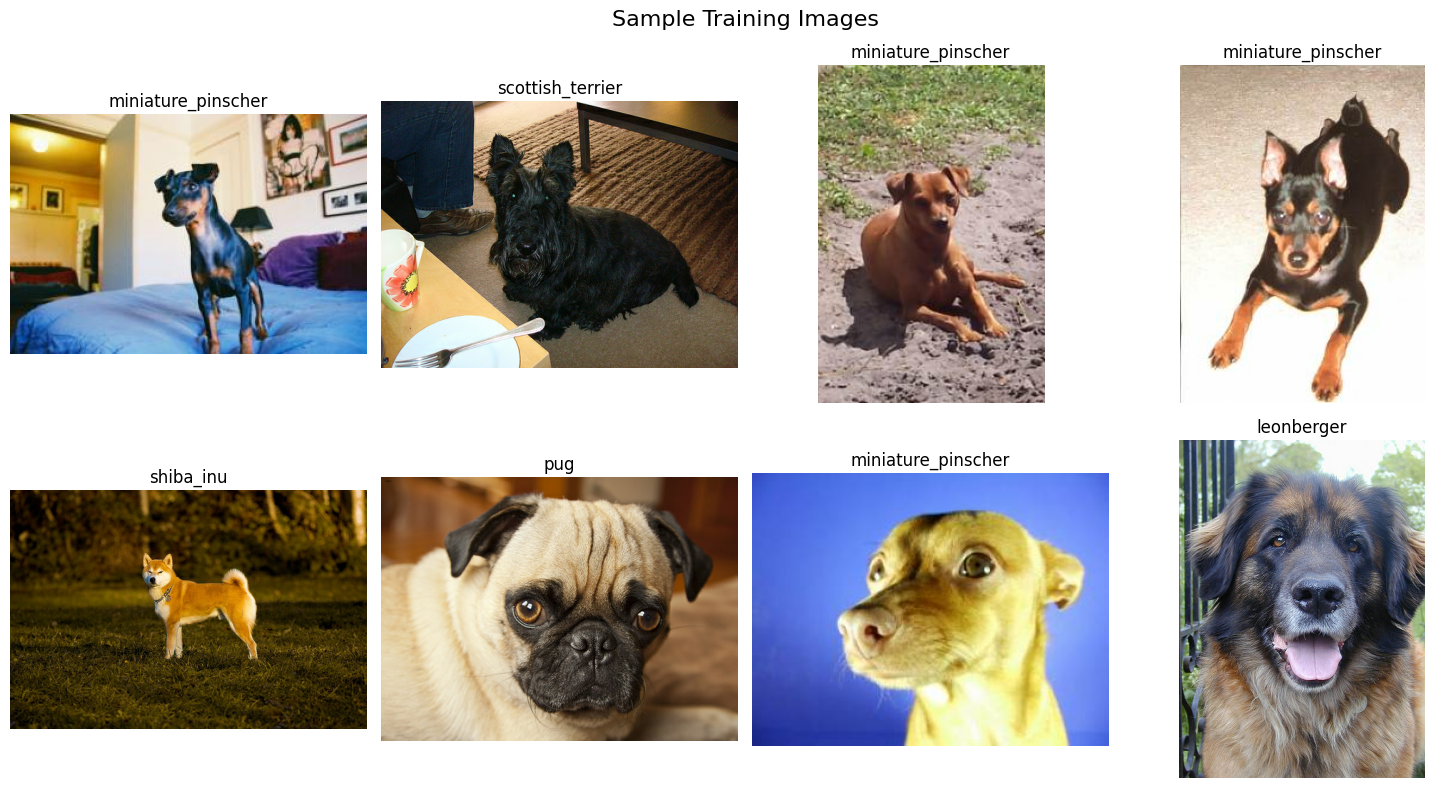

In [10]:
plt.figure(figsize=(15, 8))

# Take samples from training set
for i, (image, label) in enumerate(train_ds_raw.take(8)):
    plt.subplot(2, 4, i+1)
    plt.imshow(image)
    plt.title(f"{dog_class_names[label_map[label.numpy()]]}")
    plt.axis('off')
plt.suptitle("Sample Training Images", fontsize=16)
plt.tight_layout()
plt.show()

In [11]:
def create_cnn_model(num_classes):
    model = tf.keras.Sequential([
        # First Convolutional Block
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same',
                               input_shape=(224, 224, 3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),

        # Second Convolutional Block
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.25),

        # Third Convolutional Block
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.3),

        # Fourth Convolutional Block
        tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.3),

        # Fifth Convolutional Block
        tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Dropout(0.3),

        # Global Average Pooling and Dense Layers
        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.6),
        tf.keras.layers.Dense(256, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(0.6),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])

    return model

In [12]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    ),
]

In [13]:
model = create_cnn_model(NUM_CLASSES)
model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 5,123,641 (19.55 MB)

 Trainable params: 5,118,137 (19.52 MB)

 Non-trainable params: 5,504 (21.50 KB)

In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    steps_per_epoch=train_count // BATCH_SIZE,
    validation_steps=val_count // BATCH_SIZE
)

Epoch 1/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 154s 722ms/step - accuracy: 0.0480 - loss: 4.8498 - val_accuracy: 0.0557 - val_loss: 3.6545 - learning_rate: 0.0010
Epoch 2/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 57s 224ms/step - accuracy: 0.0486 - loss: 4.2339 - val_accuracy: 0.0394 - val_loss: 6.1493 - learning_rate: 0.0010
Epoch 3/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 230ms/step - accuracy: 0.0488 - loss: 3.9764 - val_accuracy: 0.0489 - val_loss: 4.3381 - learning_rate: 0.0010
Epoch 4/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 229ms/step - accuracy: 0.0476 - loss: 3.8397 - val_accuracy: 0.0380 - val_loss: 4.1274 - learning_rate: 0.0010
Epoch 5/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 24s 226ms/step - accuracy: 0.0632 - loss: 3.6443 - val_accuracy: 0.0584 - val_loss: 3.2887 - learning_rate: 0.0010
Epoch 6/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 228ms/step - accuracy: 0.0657 - loss: 3.5460 - val_accuracy: 0.0734 - val_loss: 3.1733 - learning_rate: 0.0010
Epoch 7/100
108/108 ━━━━━━━━━━━━━━━━━━━━ 25s 229ms/step - accur

In [15]:
model.save("dog_breed_model_tuned.keras")
print("Model saved successfully.")

Model saved successfully.


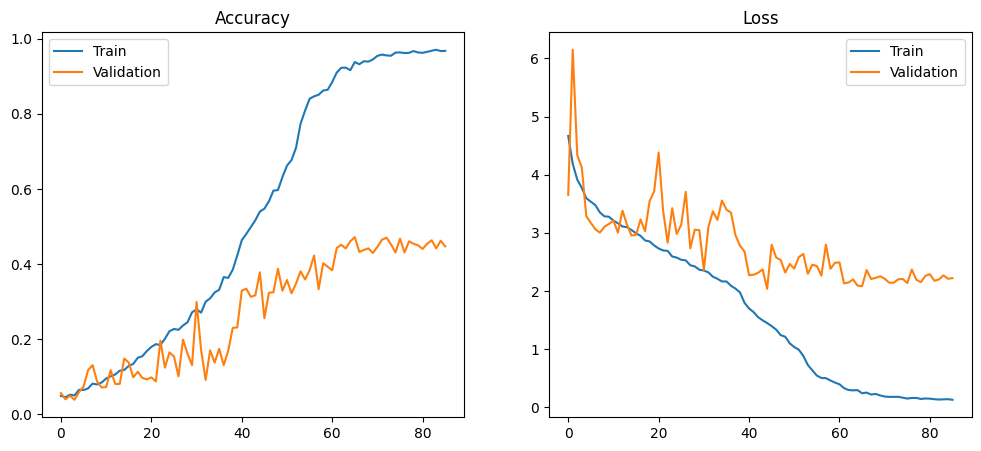

In [16]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.legend()

plt.show()

In [17]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 23s 255ms/step - accuracy: 0.4716 - loss: 2.0172
Final Test Accuracy: 0.4679
Final Test Loss: 2.0184


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [18]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=dog_class_names))


Classification Report:
                            precision    recall  f1-score   support

          american_bulldog       0.34      0.45      0.39        33
 american_pit_bull_terrier       0.15      0.23      0.18        31
              basset_hound       0.61      0.59      0.60        32
                    beagle       0.80      0.15      0.25        27
                     boxer       0.30      0.36      0.33        25
                 chihuahua       0.60      0.29      0.39        31
    english_cocker_spaniel       0.13      0.10      0.11        30
            english_setter       0.33      0.37      0.35        27
        german_shorthaired       0.46      0.62      0.52        26
            great_pyrenees       0.63      0.61      0.62        28
                  havanese       0.46      0.38      0.42        34
             japanese_chin       0.86      0.63      0.73        38
                  keeshond       0.39      0.69      0.50        26
                leonber

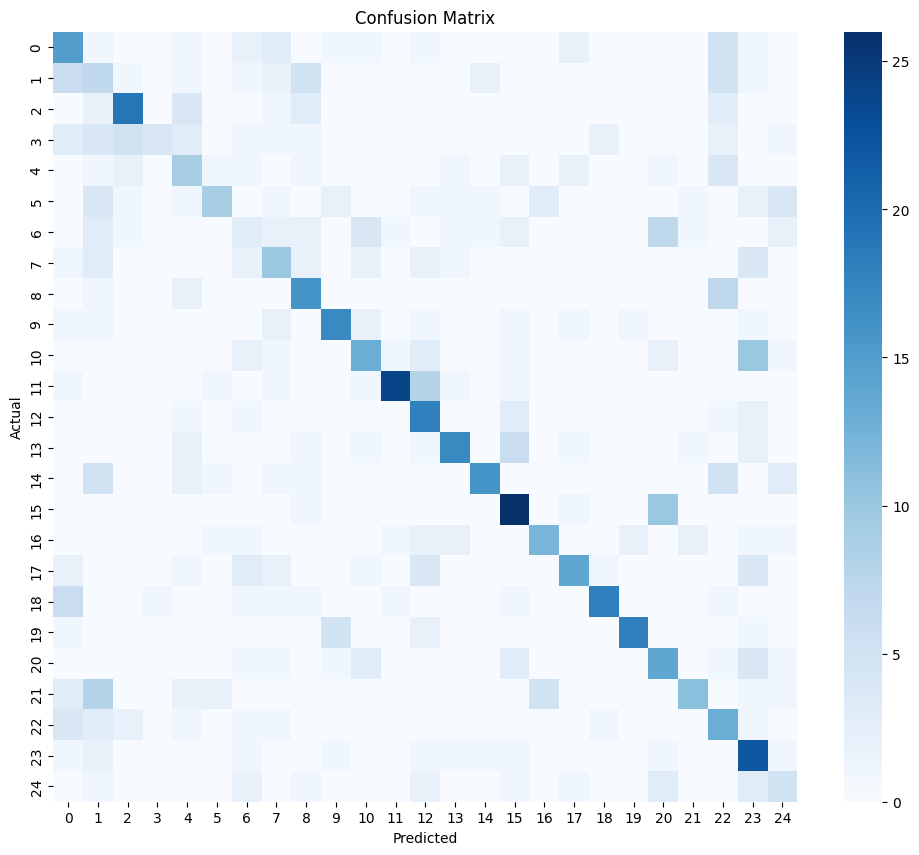

In [19]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap='Blues', annot=False, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

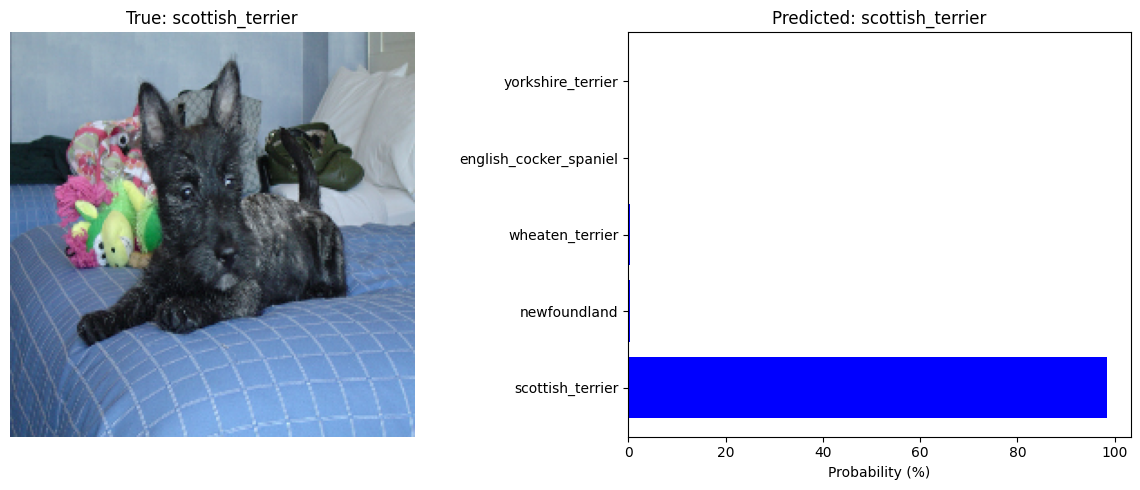

In [20]:
def predict_and_display(index):
    image, label = list(test_ds.unbatch())[index]
    input_img = tf.expand_dims(image, axis=0)

    probs = model.predict(input_img, verbose=0)[0]
    pred_class = np.argmax(probs)

    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title(f"True: {dog_class_names[label.numpy()]}")
    plt.axis('off')

    plt.subplot(1,2,2)
    # Show top 5 predictions
    top_5_indices = np.argsort(probs)[-5:][::-1]
    top_5_probs = probs[top_5_indices] * 100
    top_5_names = [dog_class_names[i] for i in top_5_indices]

    colors = ['green' if i == pred_class else 'blue' for i in range(5)]
    plt.barh(range(5), top_5_probs, color=colors)
    plt.yticks(range(5), top_5_names)
    plt.xlabel('Probability (%)')
    plt.title(f"Predicted: {dog_class_names[pred_class]}")

    plt.tight_layout()
    plt.show()

# Test prediction
predict_and_display(10)

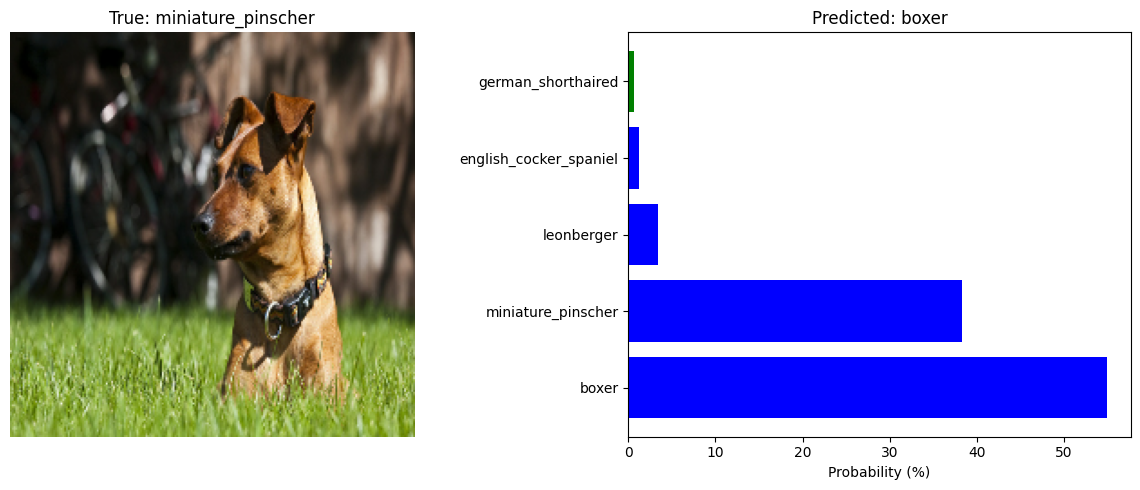

In [21]:
predict_and_display(50)

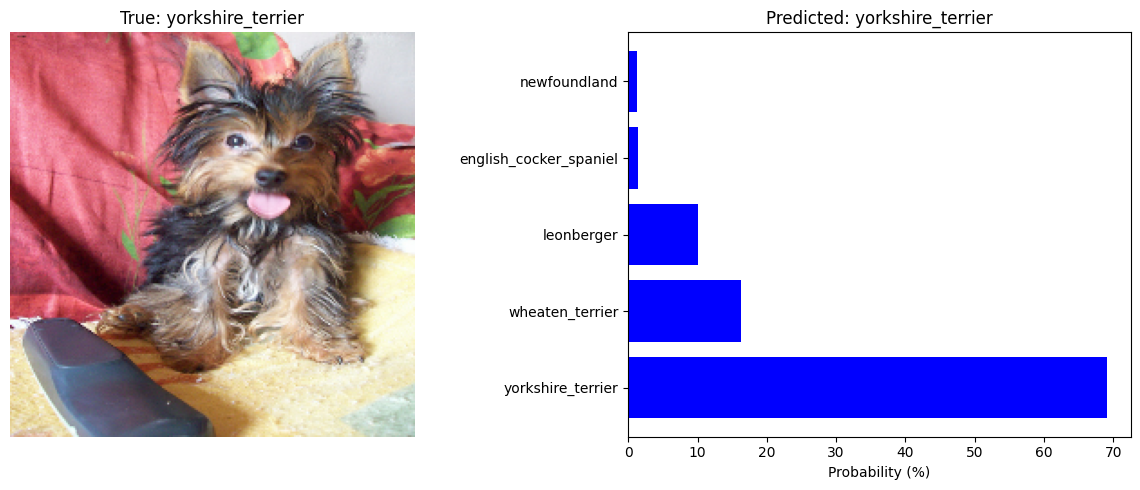

In [23]:
predict_and_display(90)